# Step 3: Univariate Analysis

**What is "univariate" analysis?** *Uni* = one, *variate* = variable. Before comparing things against each other (e.g. "revenue by country"), it's worth looking at each important column **on its own** first: what's the typical value, how spread out is it, are there extreme outliers? This builds intuition and often reveals surprises that change how you should interpret the business charts in Step 4.

We'll look at: `UnitPrice`, `Quantity`, `Revenue`, `Country`, and how many unique products/customers/orders exist.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

sales = pd.read_csv("data/sales_clean.csv", dtype={"InvoiceNo": str}, parse_dates=["InvoiceDate"])
sales.shape

(524878, 9)

## Scale of the dataset

A quick orientation before diving into distributions.

In [2]:
print(f"Line items:        {len(sales):,}")
print(f"Unique orders:      {sales['InvoiceNo'].nunique():,}")
print(f"Unique products:    {sales['StockCode'].nunique():,}")
print(f"Unique customers:   {sales['CustomerID'].nunique():,} (excludes guest checkouts)")

Line items:        524,878
Unique orders:      19,960
Unique products:    3,922
Unique customers:   4,338 (excludes guest checkouts)


About 20,000 orders across ~4,300 identified customers and almost 3,900 distinct products — so on average each order contains several different line items, and the catalog is fairly large. Keep that in mind when we later look at "top products" — with 3,900 products, even a strong seller might only be a small % of total revenue.

## `UnitPrice`: how much do individual items cost?

In [3]:
sales["UnitPrice"].describe()

count    524878.000000
mean          3.922573
std          36.093028
min           0.001000
25%           1.250000
50%           2.080000
75%           4.130000
max       13541.330000
Name: UnitPrice, dtype: float64

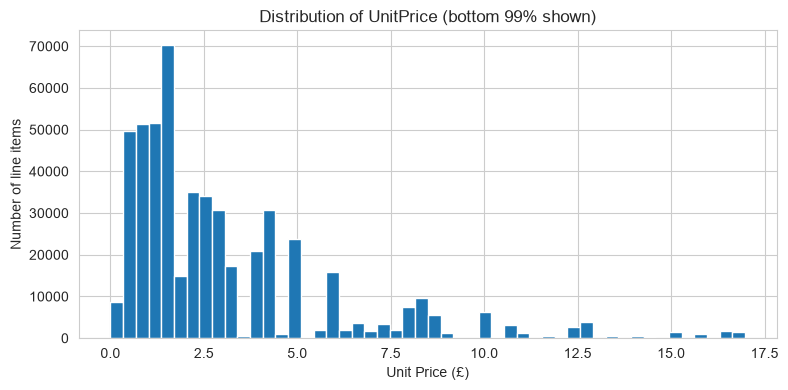

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sales[sales["UnitPrice"] <= sales["UnitPrice"].quantile(0.99)]["UnitPrice"].hist(bins=50, ax=ax)
ax.set_title("Distribution of UnitPrice (bottom 99% shown)")
ax.set_xlabel("Unit Price (£)")
ax.set_ylabel("Number of line items")
plt.tight_layout()
plt.show()

The median item costs £2.08 — this is a low-price gift/novelty retailer, not a big-ticket store. But the mean (£3.92) is almost double the median, and the max is over £13,000 — a classic **right-skewed distribution**: most items are cheap, but a few very expensive outliers pull the average up. That's why we cut off the top 1% in the chart above — otherwise the outliers would squash the histogram into one unreadable spike near zero.

## `Quantity`: how many units per line item?

In [5]:
sales["Quantity"].describe()

count    524878.000000
mean         10.616600
std         156.280031
min           1.000000
25%           1.000000
50%           4.000000
75%          11.000000
max       80995.000000
Name: Quantity, dtype: float64

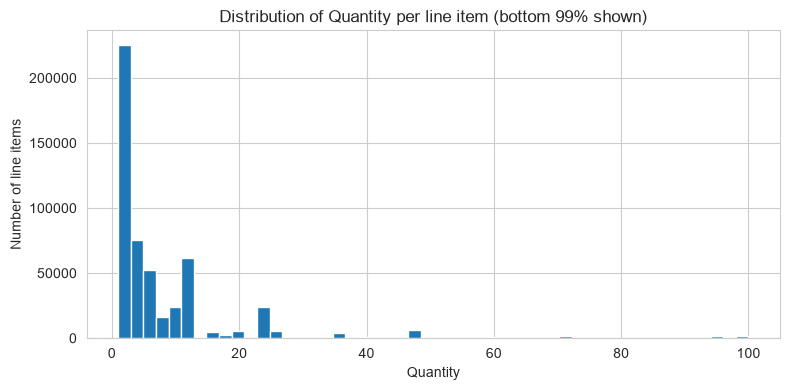

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sales[sales["Quantity"] <= sales["Quantity"].quantile(0.99)]["Quantity"].hist(bins=50, ax=ax)
ax.set_title("Distribution of Quantity per line item (bottom 99% shown)")
ax.set_xlabel("Quantity")
ax.set_ylabel("Number of line items")
plt.tight_layout()
plt.show()

Same story: median of 4 units, but a max of ~81,000 on a single line. That single row is very likely a wholesale/bulk buyer rather than a typical retail customer — something to watch out for in later analysis, since one giant order could distort a "top customer" or "top product" ranking.

## `Revenue`: how much is each line item worth?

Recall `Revenue = Quantity x UnitPrice`, calculated in Step 2.

In [7]:
sales["Revenue"].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

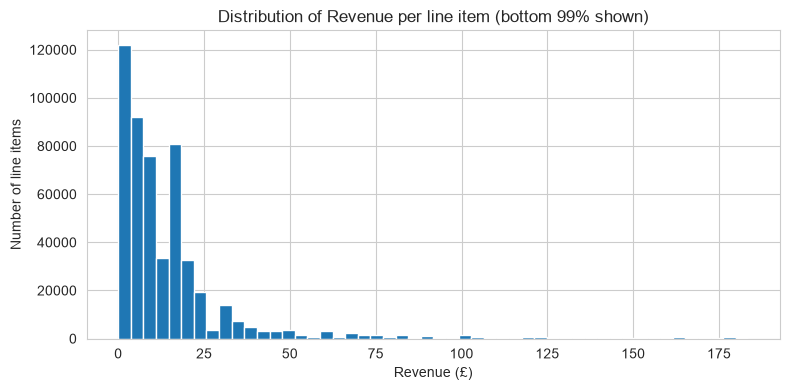

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sales[sales["Revenue"] <= sales["Revenue"].quantile(0.99)]["Revenue"].hist(bins=50, ax=ax)
ax.set_title("Distribution of Revenue per line item (bottom 99% shown)")
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("Number of line items")
plt.tight_layout()
plt.show()

Median line item is worth just £9.92, but the top line item is worth over £168,000 — the same right-skew as above, since Revenue is built from the other two skewed variables. **Takeaway for Step 4:** when we compute things like "average revenue per order", the mean will be pulled upward by a small number of huge orders. We should look at the median too, or explicitly flag big outliers, rather than trusting the mean alone.

## `Country`: where do orders come from?

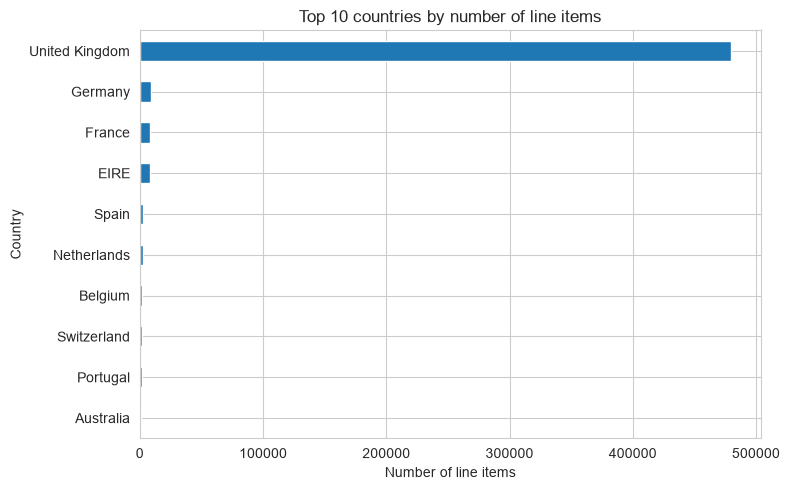

In [9]:
top_countries = sales["Country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top_countries.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 10 countries by number of line items")
ax.set_xlabel("Number of line items")
plt.tight_layout()
plt.show()

In [10]:
uk_share = (sales["Country"] == "United Kingdom").mean()
print(f"UK share of all line items: {uk_share*100:.1f}%")

UK share of all line items: 91.4%


The UK dominates completely (~91%). Germany, France, and EIRE (Ireland) are a distant second tier. This confirms what we saw in Step 1 — any "revenue by country" comparison in Step 4 needs to either focus on the UK alone, or clearly separate "UK vs. rest of world" rather than pretending all 38 countries are comparable in scale.

## Summary

- `UnitPrice`, `Quantity`, and `Revenue` are all **right-skewed**: typical orders are small and cheap, but a handful of bulk/wholesale-looking transactions are huge outliers. Medians will be more reliable than means throughout this project.
- The business is **UK-dominated** (~91% of transactions) with a long tail of smaller European markets.
- ~3,900 distinct products and ~20,000 orders mean concentration questions ("how much of revenue comes from the top N products?") are worth asking in Step 4.

These findings directly shape which charts make sense next: we now know to check for revenue concentration, to be careful with averages, and to treat the UK as the core market.